# Final Model Validation — ElasticNet ESG Score Predictor

**Milestone 6 — M6.T1, M6.T2, M6.T3**

This notebook establishes ElasticNet as the final model, validates it on the holdout test set,
analyzes the features it selected, and breaks down performance across industries and ESG pillars.

**Why ElasticNet?** Across all four ESG targets, ElasticNetCV consistently outperformed Ridge,
Lasso, and XGBoost in both test R² and 5-fold CV R². Its L1 penalty automatically reduces the
108-feature space to ~28 non-zero features, producing a sparse, interpretable model.

**Pipeline summary:**
1. Load data + apply feature engineering (Steps 7.5–7.7 from Feature_Extraction_and_Modeling)
2. Hold out 20% test set (fixed seed for reproducibility)
3. Train ElasticNetCV on training set for all four ESG targets
4. Report holdout metrics: Test R², MAE, RMSE
5. Analyze non-zero coefficients (feature importance)
6. Industry-level performance breakdown
7. Grade prediction accuracy

## Step 1 — Imports and Paths

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR        = os.path.abspath("..")
FEATURES_PATH   = os.path.join(BASE_DIR, "data", "finbert_features", "merged_features_labels.csv")
STRUCTURED_PATH = os.path.join(BASE_DIR, "data", "structured_features", "sec_fundamentals.csv")
QUALITY_PATH    = os.path.join(BASE_DIR, "data", "structured_features", "extraction_quality.csv")
OUTPUT_DIR      = os.path.join(BASE_DIR, "data", "finbert_features")

TARGETS = ['total_score', 'environment_score', 'social_score', 'governance_score']
RANDOM_STATE = 42

print("Paths configured.")
for p in [FEATURES_PATH, STRUCTURED_PATH, QUALITY_PATH]:
    print(f"  {'OK' if os.path.exists(p) else 'MISSING'}: {os.path.basename(p)}")

Paths configured.
  OK: merged_features_labels.csv
  OK: sec_fundamentals.csv
  OK: extraction_quality.csv


## Step 2 — Load Data and Feature Engineering

Replicates Steps 7.5, 7.6, and 7.7 from `Feature_Extraction_and_Modeling.ipynb` exactly.

In [2]:
# ── Load raw FinBERT features ─────────────────────────────────────────────────
df = pd.read_csv(FEATURES_PATH)
print(f"Raw dataset: {df.shape[0]} companies, {df.shape[1]} columns")

# ── Step 7.5: Feature Engineering ────────────────────────────────────────────
# Zero-variance and near-universal features to drop
ZERO_VAR = [
    'num_sections',
    'kw_employee_welfare_present',
    'has_women_leadership',
    'count_women_leadership',
    'has_board_independence',
    'count_board_independence',
]
NEAR_UNIVERSAL = [
    'kw_ethics_compliance_present',
    'kw_transparency_present',
    'kw_regulatory_penalties_present',
    'kw_diversity_present',
    'kw_board_governance_present',
]
DROP_COLS = ZERO_VAR + NEAR_UNIVERSAL

eng = df.copy()

# Clip pos_neg_ratio outliers at 99th percentile
for pillar in ['E', 'S', 'G']:
    col = f'{pillar}_pos_neg_ratio'
    cap = eng[col].quantile(0.99)
    eng[col] = eng[col].clip(upper=cap)

# Log-transform keyword frequency features
kw_freq_cols = [c for c in eng.columns if c.startswith('kw_') and c.endswith('_freq')]
for col in kw_freq_cols:
    eng[f'{col}_log'] = np.log1p(eng[col])
DROP_COLS += kw_freq_cols

eng.drop(columns=[c for c in DROP_COLS if c in eng.columns], inplace=True)

# Add one-hot industry dummies
ind_dummies = pd.get_dummies(eng['industry'], prefix='ind')
eng = pd.concat([eng, ind_dummies], axis=1)

print(f"After feature engineering: {eng.shape[0]} companies, {eng.shape[1]} columns")

Raw dataset: 332 companies, 83 columns
After feature engineering: 332 companies, 110 columns


In [3]:
# ── Step 7.6: Merge SEC EDGAR Structured Features ────────────────────────────
STRUCTURED_COLS = [
    'log_total_assets',
    'log_public_float',
    'debt_to_assets',
    'profit_margin',
    'return_on_equity',
]

if os.path.exists(STRUCTURED_PATH):
    sec_df = pd.read_csv(STRUCTURED_PATH)
    sec_df['ticker'] = sec_df['ticker'].str.upper()

    available = [c for c in STRUCTURED_COLS if c in sec_df.columns]
    sec_merge = sec_df[['ticker'] + available].copy()

    # Industry-median imputation, then global-median fallback
    sec_merge = sec_merge.merge(
        eng[['ticker', 'industry']].drop_duplicates(), on='ticker', how='left'
    )
    for col in available:
        ind_medians = sec_merge.groupby('industry')[col].transform('median')
        global_median = sec_merge[col].median()
        sec_merge[col] = sec_merge[col].fillna(ind_medians).fillna(global_median)

    # Winsorize ratios at 1st/99th percentile
    ratio_cols = ['debt_to_assets', 'profit_margin', 'return_on_equity']
    for col in [c for c in ratio_cols if c in available]:
        lo, hi = sec_merge[col].quantile([0.01, 0.99])
        sec_merge[col] = sec_merge[col].clip(lo, hi)

    sec_merge.drop(columns=['industry'], inplace=True)
    eng = eng.merge(sec_merge, on='ticker', how='left')

    # Remaining NaN fallback (companies not in SEC dataset)
    for col in available:
        eng[col] = eng[col].fillna(eng[col].median())

    print(f"Structured features merged: {len(available)} columns added")
    print(f"Dataset shape: {eng.shape}")
else:
    print("[SKIP] sec_fundamentals.csv not found")

Structured features merged: 5 columns added
Dataset shape: (332, 115)


In [4]:
# ── Step 7.7: Filter Bad Extractions ─────────────────────────────────────────
if os.path.exists(QUALITY_PATH):
    eq_df = pd.read_csv(QUALITY_PATH)
    eq_df['ticker'] = eq_df['ticker'].str.upper()
    eng = eng.merge(eq_df[['ticker', 'bad_extraction']], on='ticker', how='left')
    eng['bad_extraction'] = eng['bad_extraction'].fillna(0).astype(int)

    critical = eng[eng['bad_extraction'] == 2]['ticker'].tolist()
    pre = len(eng)
    eng = eng[eng['bad_extraction'] < 2].copy()
    eng.drop(columns=['bad_extraction'], inplace=True)

    print(f"Removed {pre - len(eng)} critical bad-extraction companies: {critical}")
    print(f"Final dataset: {len(eng)} companies")
else:
    print("[SKIP] extraction_quality.csv not found")

print(f"\nFinal engineered dataset: {eng.shape[0]} companies x {eng.shape[1]} columns")

Removed 9 critical bad-extraction companies: ['ACNB', 'AKTS', 'AOS', 'COST', 'DXCM', 'EBAY', 'LOW', 'NTAP', 'TER']
Final dataset: 323 companies

Final engineered dataset: 323 companies x 115 columns


## Step 3 — Train/Test Split and Model Training

80/20 split (same seed as all prior experiments). ElasticNetCV selects alpha and l1_ratio
via 5-fold CV on the training set — no separate tuning step needed.

In [5]:
EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in eng.columns if c not in EXCLUDE]

print(f"Feature matrix: {len(feature_cols)} features")

# Build feature groups for later analysis
finbert_cols    = [c for c in feature_cols if c.split('_')[0] in ('E','S','G') and not c.startswith('ind_')]
kw_cols         = [c for c in feature_cols if c.endswith('_freq_log') or c.endswith('_present')]
struct_cols     = [c for c in STRUCTURED_COLS if c in feature_cols]
doc_cols        = [c for c in feature_cols if c in ['doc_length','business_length','risk_factors_length',
                   'mda_length','business_pct','risk_factors_pct','mda_pct',
                   'E_coverage_pct','S_coverage_pct','G_coverage_pct']]
ind_cols        = [c for c in feature_cols if c.startswith('ind_')]
quant_cols      = [c for c in feature_cols if c.startswith('has_') or c.startswith('count_')]

print(f"  FinBERT sentiment:  {len(finbert_cols)}")
print(f"  Keyword (log freq): {len(kw_cols)}")
print(f"  Structured (SEC):   {len(struct_cols)}")
print(f"  Document structure: {len(doc_cols)}")
print(f"  Industry dummies:   {len(ind_cols)}")
print(f"  Quantitative:       {len(quant_cols)}")

Feature matrix: 108 features
  FinBERT sentiment:  27
  Keyword (log freq): 22
  Structured (SEC):   5
  Document structure: 10
  Industry dummies:   38
  Quantitative:       9


In [6]:
X = eng[feature_cols].fillna(0).values

# Scale features — ElasticNet is sensitive to feature scale
scaler = StandardScaler()

results   = {}
models    = {}
test_sets = {}

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

for target in TARGETS:
    y = eng[target].values

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, eng.index, test_size=0.2, random_state=RANDOM_STATE
    )

    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = ElasticNetCV(
        l1_ratio=l1_ratios,
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=10000,
        n_alphas=100
    )
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    test_r2  = 1 - ss_res / ss_tot
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    n_nonzero = np.sum(model.coef_ != 0)

    results[target] = {
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'alpha': model.alpha_,
        'l1_ratio': model.l1_ratio_,
        'n_nonzero': n_nonzero,
        'coef': model.coef_,
        'y_pred': y_pred,
        'y_test': y_test,
        'idx_test': idx_test,
    }
    models[target]    = model
    test_sets[target] = (X_test_s, y_test, idx_test)

    print(f"{target:25s}  R²={test_r2:+.4f}  MAE={test_mae:.2f}  "
          f"RMSE={test_rmse:.2f}  alpha={model.alpha_:.4f}  "
          f"l1_ratio={model.l1_ratio_:.2f}  nonzero={n_nonzero}/{len(feature_cols)}")

total_score                R²=+0.0648  MAE=145.66  RMSE=172.56  alpha=14.1279  l1_ratio=0.99  nonzero=27/108
environment_score          R²=+0.0784  MAE=104.10  RMSE=116.25  alpha=9.4409  l1_ratio=0.95  nonzero=30/108
social_score               R²=+0.1726  MAE=31.45  RMSE=40.34  alpha=4.2776  l1_ratio=0.95  nonzero=31/108
governance_score           R²=-0.0003  MAE=36.33  RMSE=42.94  alpha=74.0998  l1_ratio=0.10  nonzero=0/108


## Step 4 — Holdout Evaluation Summary (M6.T1)

In [7]:
# ── Metrics table ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    t: {
        'Test R²':      round(results[t]['test_r2'],   4),
        'Test MAE':     round(results[t]['test_mae'],  2),
        'Test RMSE':    round(results[t]['test_rmse'], 2),
        'Alpha':        round(results[t]['alpha'],     4),
        'L1 Ratio':     round(results[t]['l1_ratio'],  2),
        'Non-zero Features': int(results[t]['n_nonzero']),
    }
    for t in TARGETS
}).T

print("=" * 70)
print("Final ElasticNet Model — Holdout Test Set Performance")
print("=" * 70)
print(metrics_df.to_string())
print()
print(f"Total features in model: {len(feature_cols)}")
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'final_model_metrics.csv'))
print(f"Saved to data/finbert_features/final_model_metrics.csv")

Final ElasticNet Model — Holdout Test Set Performance
                   Test R²  Test MAE  Test RMSE    Alpha  L1 Ratio  Non-zero Features
total_score         0.0648    145.66     172.56  14.1279      0.99               27.0
environment_score   0.0784    104.10     116.25   9.4409      0.95               30.0
social_score        0.1726     31.45      40.34   4.2776      0.95               31.0
governance_score   -0.0003     36.33      42.94  74.0998      0.10                0.0

Total features in model: 108
Saved to data/finbert_features/final_model_metrics.csv


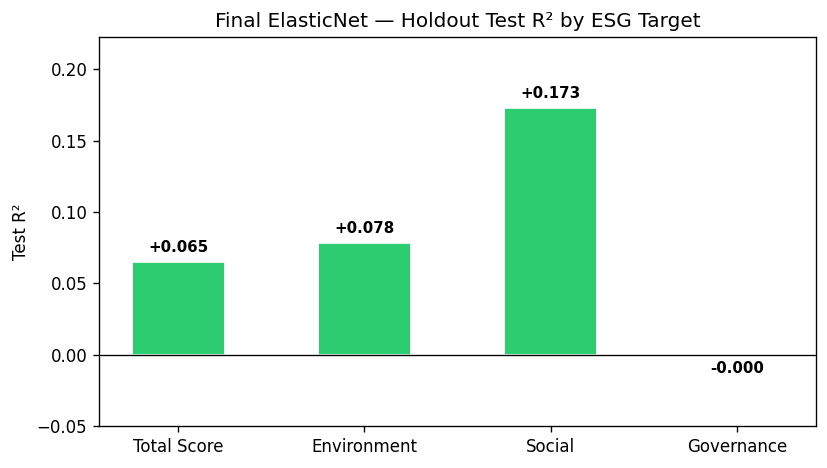

In [8]:
# ── R² bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

target_labels = ['Total Score', 'Environment', 'Social', 'Governance']
r2_vals = [results[t]['test_r2'] for t in TARGETS]
colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in r2_vals]

bars = ax.bar(target_labels, r2_vals, color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Test R²')
ax.set_title('Final ElasticNet — Holdout Test R² by ESG Target')
ax.set_ylim(min(r2_vals) - 0.05, max(r2_vals) + 0.05)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.005 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_r2_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Feature Importance: Non-Zero Coefficients (M6.T2)

For a linear model, the standardized coefficients directly quantify feature importance.
Features with coefficient = 0 were eliminated by the L1 penalty.

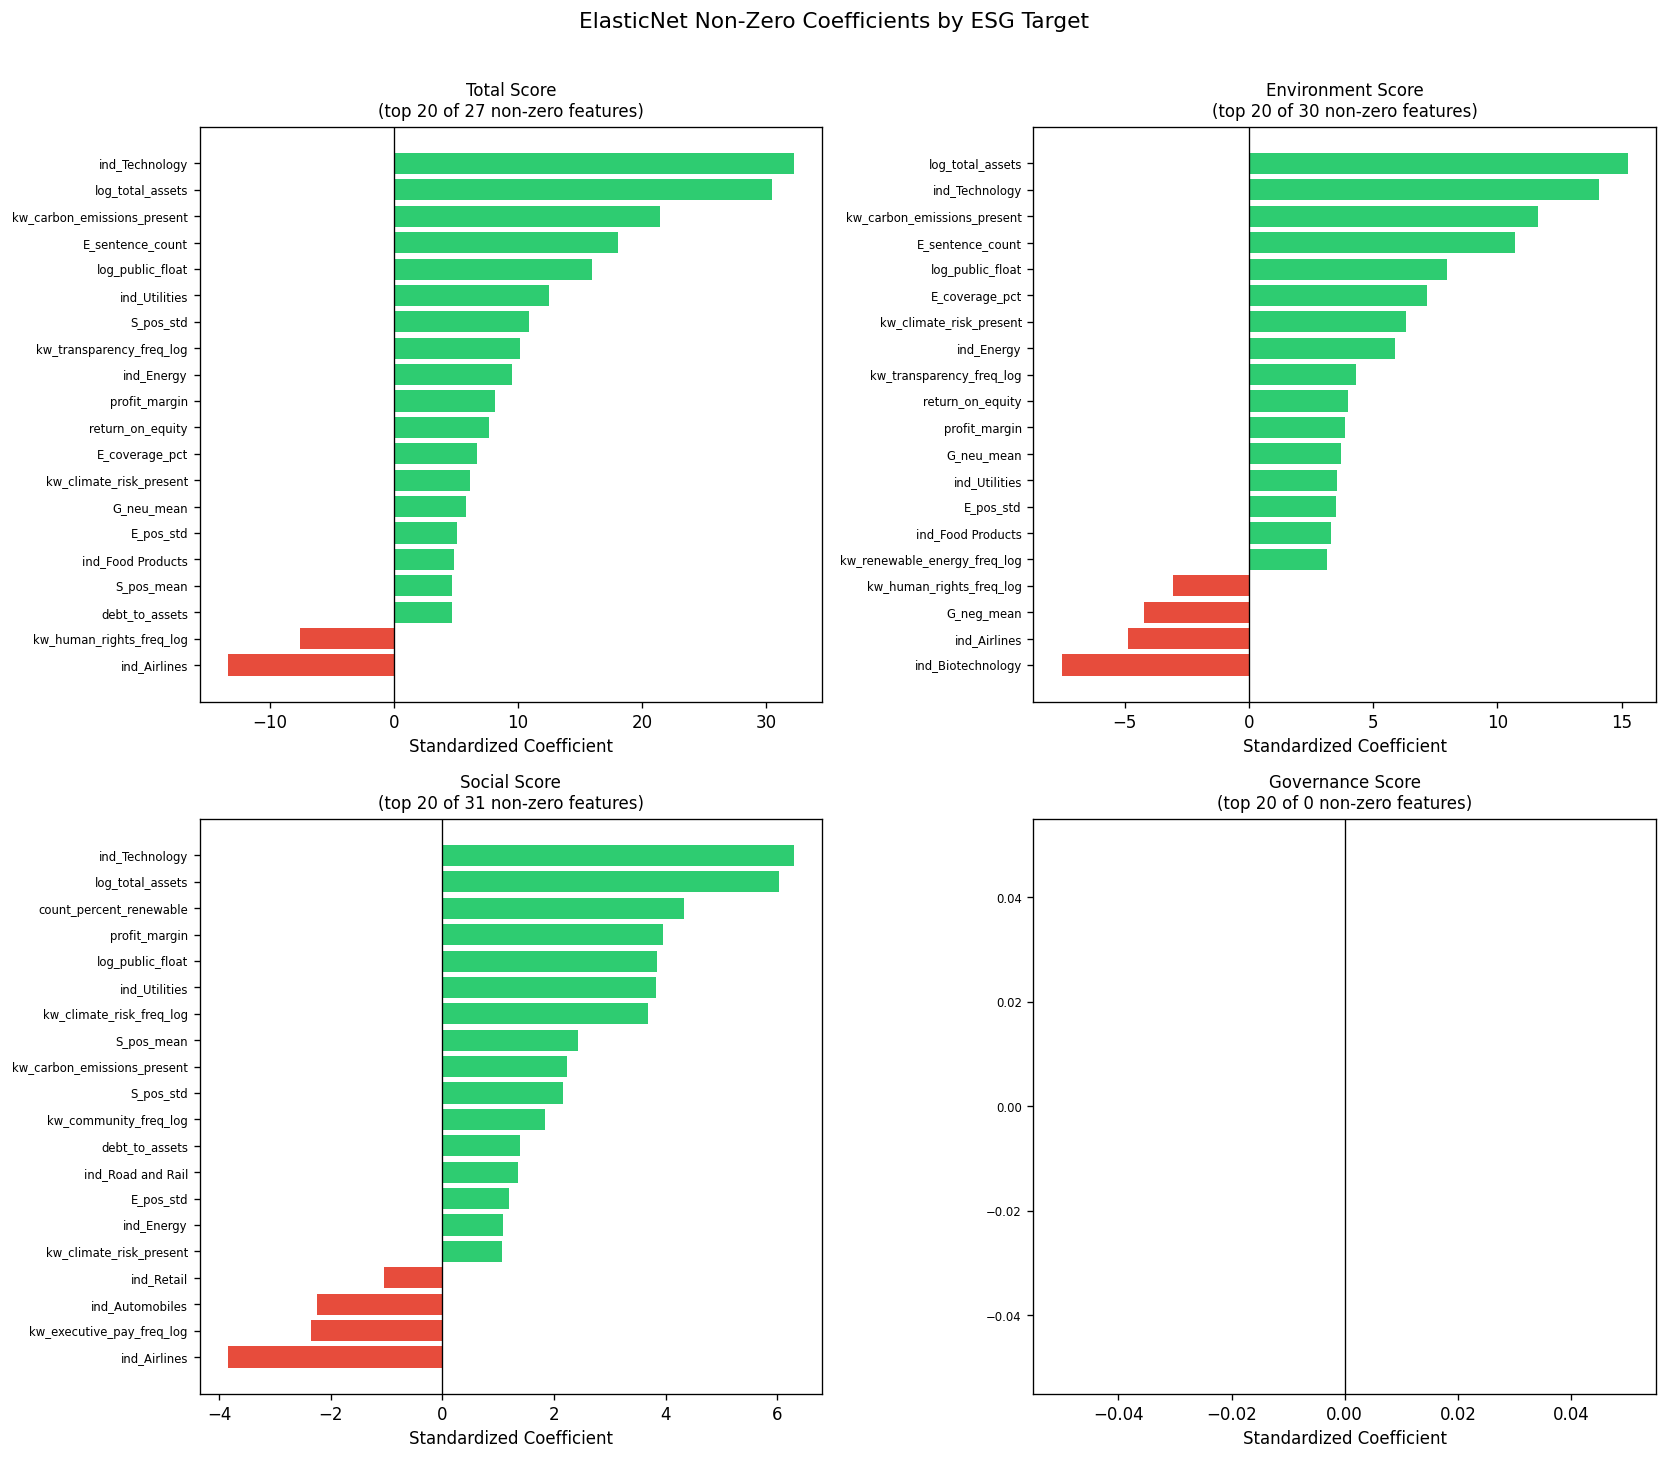

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

coef_dfs = {}

for ax, target in zip(axes, TARGETS):
    coef = results[target]['coef']
    coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': coef})
    coef_df = coef_df[coef_df['coefficient'] != 0].copy()
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)
    coef_df = coef_df.sort_values('coefficient')

    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['coefficient']]
    ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{target.replace("_", " ").title()}\n'
                 f'(top 20 of {int(results[target]["n_nonzero"])} non-zero features)',
                 fontsize=10)
    ax.set_xlabel('Standardized Coefficient')
    ax.tick_params(axis='y', labelsize=7)

    coef_dfs[target] = coef_df

plt.suptitle('ElasticNet Non-Zero Coefficients by ESG Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Feature group breakdown of non-zero features ─────────────────────────────
print("Non-zero feature counts by group:\n")
print(f"{'Target':<25} {'FinBERT':>8} {'Keyword':>8} {'Structured':>11} "
      f"{'Doc':>5} {'Industry':>9} {'Quant':>6} {'Total':>6}")
print("-" * 80)

group_map = {
    'FinBERT':     finbert_cols,
    'Keyword':     kw_cols,
    'Structured':  struct_cols,
    'Doc':         doc_cols,
    'Industry':    ind_cols,
    'Quant':       quant_cols,
}

for target in TARGETS:
    coef = pd.Series(results[target]['coef'], index=feature_cols)
    nonzero = coef[coef != 0].index.tolist()
    counts = {g: sum(1 for f in nonzero if f in cols) for g, cols in group_map.items()}
    print(f"{target:<25} {counts['FinBERT']:>8} {counts['Keyword']:>8} "
          f"{counts['Structured']:>11} {counts['Doc']:>5} {counts['Industry']:>9} "
          f"{counts['Quant']:>6} {sum(counts.values()):>6}")

Non-zero feature counts by group:

Target                     FinBERT  Keyword  Structured   Doc  Industry  Quant  Total
--------------------------------------------------------------------------------
total_score                      6        6           5     2         8      1     28
environment_score                9        6           5     2         8      1     31
social_score                     4        9           5     0        10      3     31
governance_score                 0        0           0     0         0      0      0


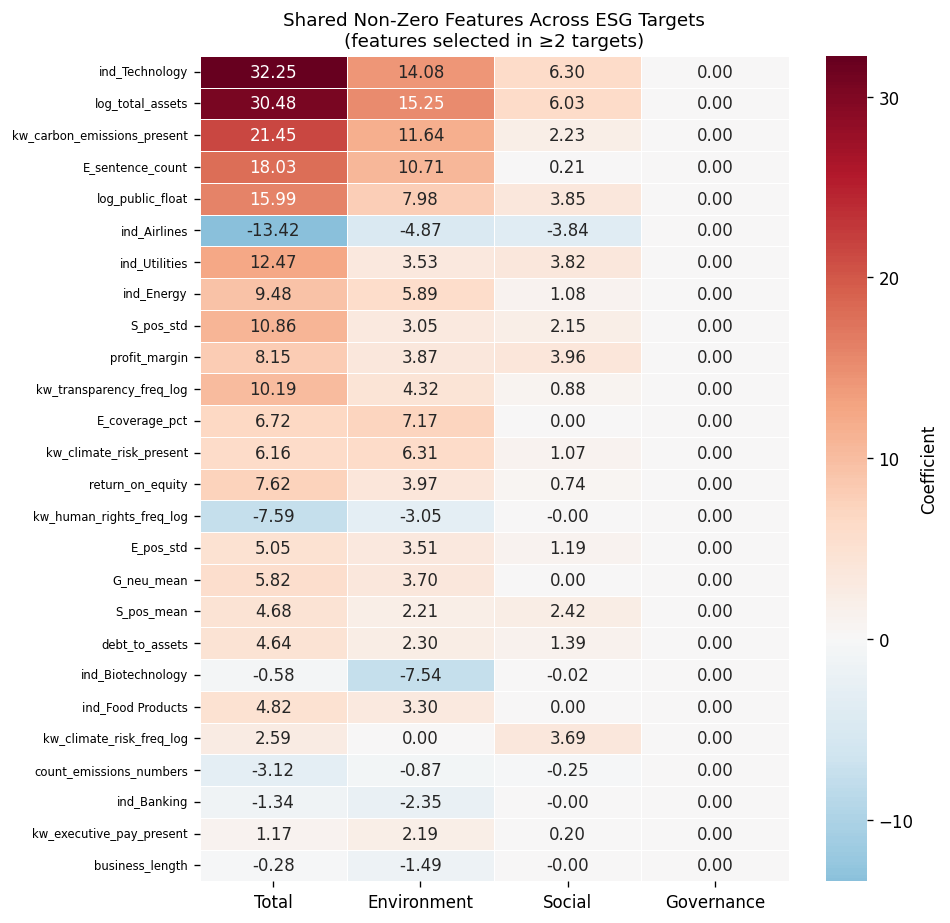

In [11]:
# ── Cross-target coefficient heatmap for features selected in 2+ targets ─────
all_nonzero = set()
for target in TARGETS:
    coef = pd.Series(results[target]['coef'], index=feature_cols)
    all_nonzero.update(coef[coef != 0].index.tolist())

# Keep features that appear in at least 2 targets
shared = []
for feat in all_nonzero:
    count = sum(1 for t in TARGETS
                if results[t]['coef'][feature_cols.index(feat)] != 0)
    if count >= 2:
        shared.append(feat)

heat_df = pd.DataFrame(
    {t: pd.Series(results[t]['coef'], index=feature_cols)[shared] for t in TARGETS},
    index=shared
)
# Sort by mean absolute coefficient
heat_df['_abs_mean'] = heat_df.abs().mean(axis=1)
heat_df = heat_df.sort_values('_abs_mean', ascending=False).drop(columns='_abs_mean').head(30)

fig, ax = plt.subplots(figsize=(8, max(6, len(heat_df) * 0.3)))
sns.heatmap(
    heat_df,
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Coefficient'}
)
ax.set_title('Shared Non-Zero Features Across ESG Targets\n(features selected in ≥2 targets)',
             fontsize=11)
ax.set_xticklabels([t.replace('_score','').replace('_',' ').title() for t in TARGETS])
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_shared_features_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Industry-Level Performance Breakdown (M6.T3)

Computes per-industry R² and MAE for each ESG target.
Industries with fewer than 5 test-set companies are grouped as 'Other'.

In [12]:
MIN_INDUSTRY_N = 5

industry_records = []

for target in TARGETS:
    idx_test = results[target]['idx_test']
    y_test   = results[target]['y_test']
    y_pred   = results[target]['y_pred']
    industries = eng.loc[idx_test, 'industry'].values

    temp = pd.DataFrame({'industry': industries, 'y_test': y_test, 'y_pred': y_pred})

    counts = temp['industry'].value_counts()
    temp['industry'] = temp['industry'].where(temp['industry'].map(counts) >= MIN_INDUSTRY_N,
                                               other='Other')

    for ind, grp in temp.groupby('industry'):
        if len(grp) < 2:
            continue
        ss_res = np.sum((grp['y_test'] - grp['y_pred']) ** 2)
        ss_tot = np.sum((grp['y_test'] - grp['y_test'].mean()) ** 2)
        r2  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        mae = mean_absolute_error(grp['y_test'], grp['y_pred'])
        industry_records.append({'target': target, 'industry': ind, 'n': len(grp),
                                  'r2': r2, 'mae': mae})

ind_df = pd.DataFrame(industry_records)

# Pivot for display
ind_r2_pivot = ind_df.pivot(index='industry', columns='target', values='r2').round(3)
ind_r2_pivot = ind_r2_pivot.reindex(columns=TARGETS)
ind_r2_pivot.columns = [c.replace('_score','').replace('_',' ').title() for c in TARGETS]

print("Industry-level Test R² (ElasticNet)")
print("=" * 65)
print(ind_r2_pivot.to_string())

ind_df.to_csv(os.path.join(OUTPUT_DIR, 'final_model_industry_performance.csv'), index=False)
print("\nSaved to data/finbert_features/final_model_industry_performance.csv")

Industry-level Test R² (ElasticNet)
                   Total  Environment  Social  Governance
industry                                                 
Biotechnology     -0.105       -0.114  -0.403      -0.004
Consumer products  0.197        0.158  -0.173      -0.113
Health Care        0.091        0.004   0.084      -0.056
Other             -0.073       -0.120   0.268      -0.005
Technology        -0.198       -0.017  -0.433      -0.010

Saved to data/finbert_features/final_model_industry_performance.csv


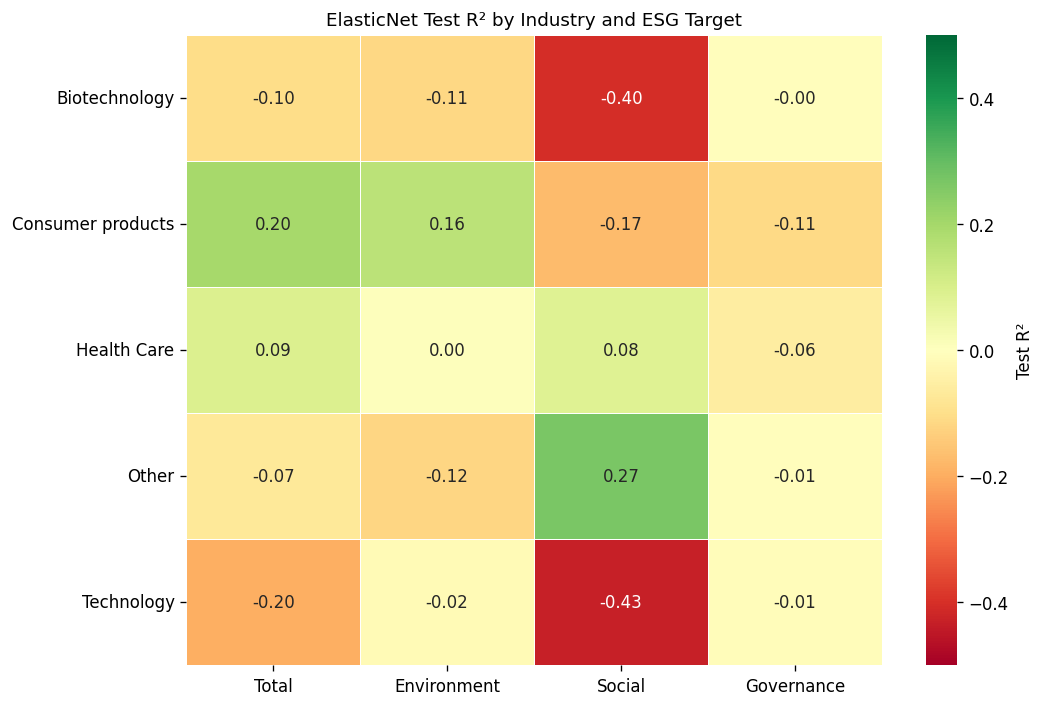

In [13]:
# ── Industry R² heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(6, len(ind_r2_pivot) * 0.4)))

sns.heatmap(
    ind_r2_pivot,
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt='.2f', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Test R²'}
)
ax.set_title('ElasticNet Test R² by Industry and ESG Target', fontsize=11)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_industry_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

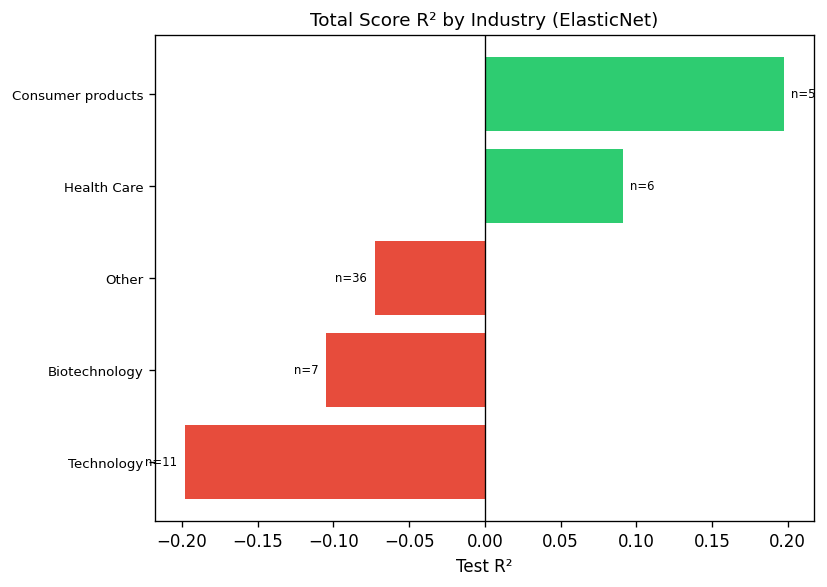

In [14]:
# ── Per-industry R² bar chart for total_score ─────────────────────────────────
total_ind = ind_df[ind_df['target'] == 'total_score'].sort_values('r2', ascending=True)

fig, ax = plt.subplots(figsize=(7, max(5, len(total_ind) * 0.35)))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in total_ind['r2']]
ax.barh(total_ind['industry'], total_ind['r2'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

for i, (_, row) in enumerate(total_ind.iterrows()):
    ax.text(row['r2'] + (0.005 if row['r2'] >= 0 else -0.005),
            i, f"n={int(row['n'])}", va='center', ha='left' if row['r2'] >= 0 else 'right',
            fontsize=7)

ax.set_xlabel('Test R²')
ax.set_title('Total Score R² by Industry (ElasticNet)', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_industry_total_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Grade Prediction Accuracy

Converts predicted total_score to letter grades using empirical boundaries derived from the
training set, then evaluates accuracy against true grades.

In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Derive empirical grade boundaries from training set
idx_test_total = results['total_score']['idx_test']
train_mask = ~eng.index.isin(idx_test_total)
train_df   = eng[train_mask]

boundaries = (
    train_df.groupby('total_grade')['total_score'].min()
    .sort_values()
    .to_dict()
)
print("Empirical grade boundaries (from training set):")
for grade, min_score in sorted(boundaries.items(), key=lambda x: x[1]):
    print(f"  {grade}: >= {min_score:.1f}")

def score_to_grade(scores, boundaries):
    grades_sorted = sorted(boundaries.items(), key=lambda x: x[1])
    def _convert(s):
        grade = grades_sorted[0][0]
        for g, min_s in grades_sorted:
            if s >= min_s:
                grade = g
        return grade
    if np.isscalar(scores):
        return _convert(scores)
    return [_convert(s) for s in scores]

y_test_total = results['total_score']['y_test']
y_pred_total = results['total_score']['y_pred']

true_grades = eng.loc[idx_test_total, 'total_grade'].values
pred_grades = score_to_grade(y_pred_total, boundaries)

print("\nGrade Classification Report (predicted score → grade):")
print(classification_report(true_grades, pred_grades, zero_division=0))

Empirical grade boundaries (from training set):
  B: >= 600.0
  BB: >= 752.0
  BBB: >= 903.0
  A: >= 1202.0

Grade Classification Report (predicted score → grade):
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           B       0.00      0.00      0.00         9
          BB       0.14      0.25      0.18         8
         BBB       0.67      0.81      0.73        42

    accuracy                           0.55        65
   macro avg       0.20      0.26      0.23        65
weighted avg       0.45      0.55      0.49        65



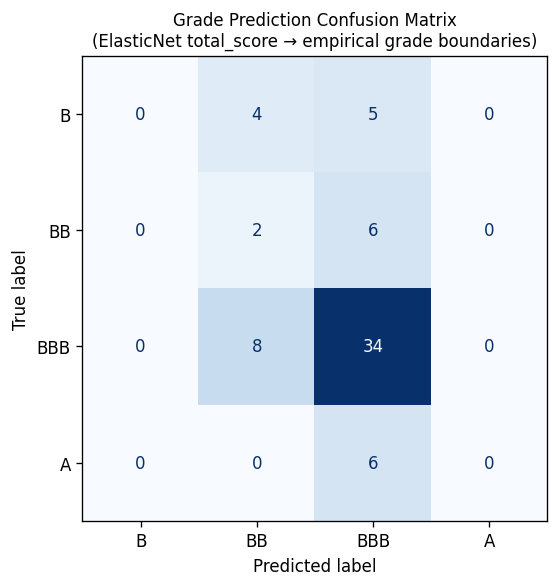


Exact grade accuracy: 55.4%


In [16]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
grade_order = sorted(set(true_grades) | set(pred_grades),
                     key=lambda g: boundaries.get(g, 0))

cm = confusion_matrix(true_grades, pred_grades, labels=grade_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grade_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Grade Prediction Confusion Matrix\n'
             '(ElasticNet total_score → empirical grade boundaries)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_grade_confusion.png'),
            dpi=150, bbox_inches='tight')
plt.show()

exact_acc = np.mean(np.array(true_grades) == np.array(pred_grades))
print(f"\nExact grade accuracy: {exact_acc:.1%}")

## Step 8 — Residual Analysis

Examines where the model is wrong — which companies have the largest prediction errors
and whether residuals are systematic.

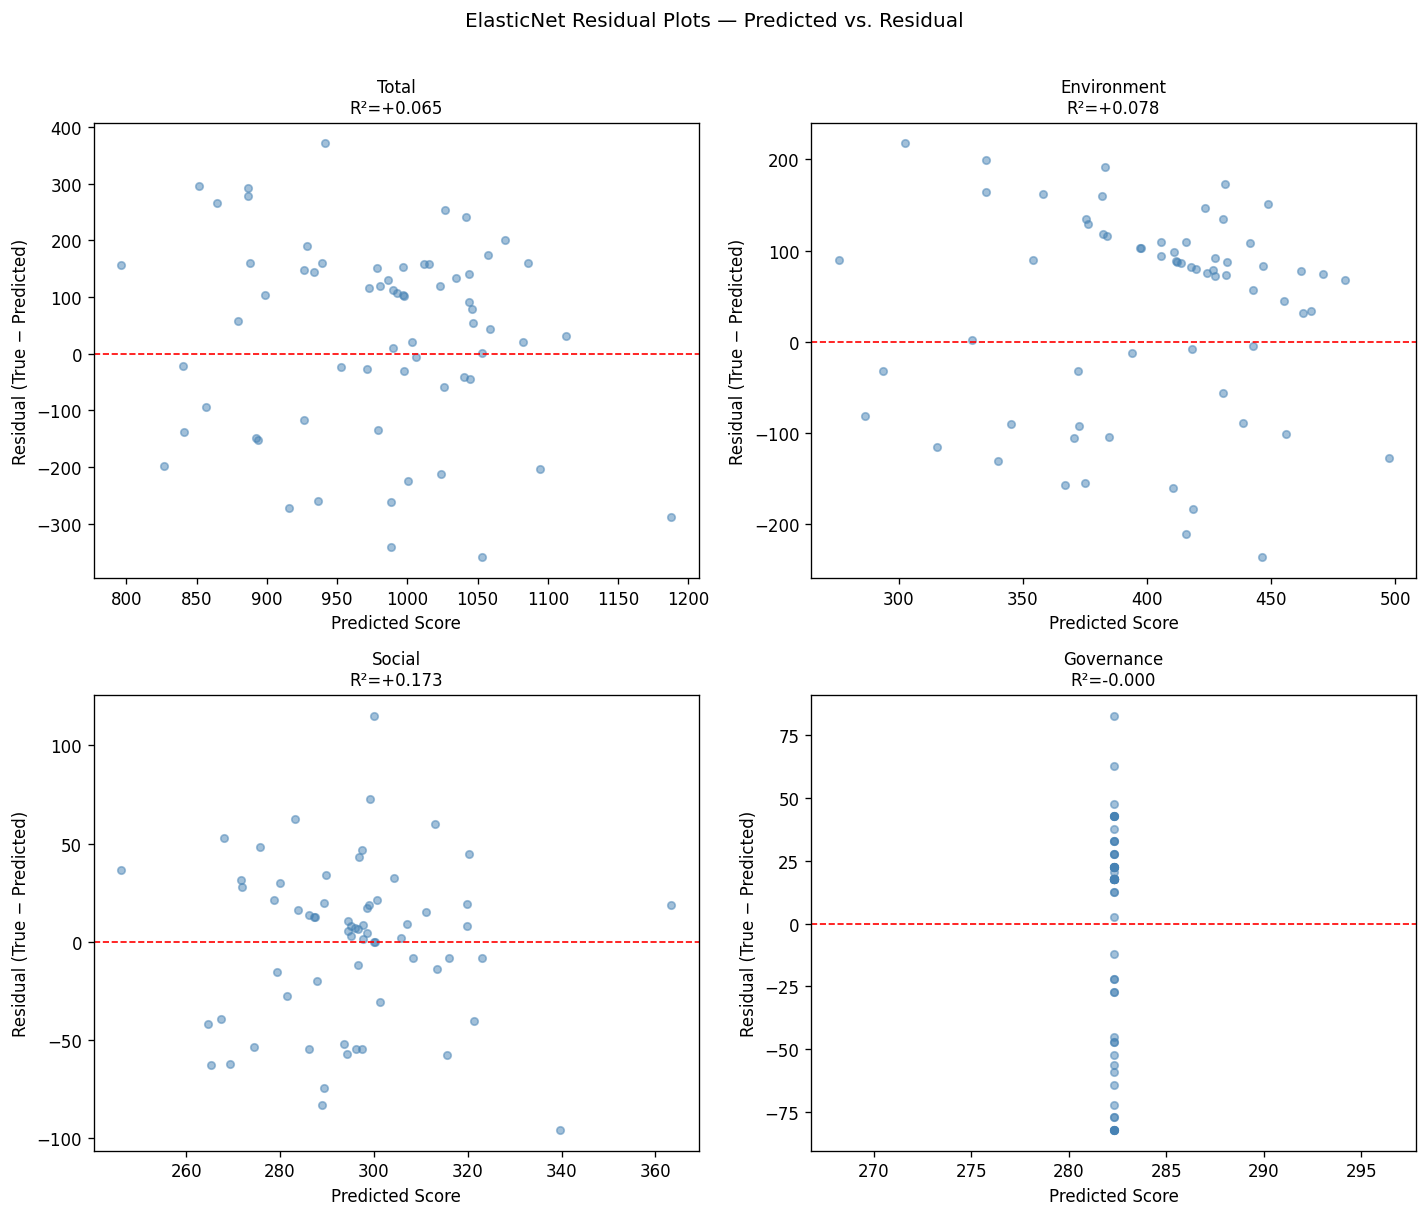

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, target in zip(axes, TARGETS):
    y_test = results[target]['y_test']
    y_pred = results[target]['y_pred']
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color='steelblue')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted Score')
    ax.set_ylabel('Residual (True − Predicted)')
    ax.set_title(f'{target.replace("_score","").replace("_"," ").title()}\n'
                 f'R²={results[target]["test_r2"]:+.3f}', fontsize=10)

plt.suptitle('ElasticNet Residual Plots — Predicted vs. Residual', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_residuals.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Largest residual companies (total_score) ──────────────────────────────────
idx_test_total = results['total_score']['idx_test']
y_test  = results['total_score']['y_test']
y_pred  = results['total_score']['y_pred']

error_df = eng.loc[idx_test_total, ['ticker', 'industry', 'total_score', 'total_grade']].copy()
error_df['predicted']  = y_pred
error_df['residual']   = y_test - y_pred
error_df['abs_error']  = error_df['residual'].abs()
error_df = error_df.sort_values('abs_error', ascending=False)

print("Top 15 largest prediction errors (total_score):")
print(error_df.head(15).to_string(index=False))

Top 15 largest prediction errors (total_score):
ticker             industry  total_score total_grade   predicted    residual  abs_error
   REG          Real Estate         1312           A  941.272015  370.727985 370.727985
  CARR             Building          694           B 1053.437331 -359.437331 359.437331
  ULTA               Retail          647           B  988.443903 -341.443903 341.443903
  AGIO        Biotechnology         1148         BBB  851.709285  296.290715 296.290715
  ALLE             Building         1179         BBB  886.414147  292.585853 292.585853
  PYPL           Technology          899          BB 1187.880774 -288.880774 288.880774
  ALLO        Biotechnology         1164         BBB  886.513997  277.486003 277.486003
  ADUS          Health Care          643           B  915.684661 -272.684661 272.684661
  AIRG Electrical Equipment         1130         BBB  864.829371  265.170629 265.170629
   DHI    Consumer products          726           B  988.313216 -262.31

## Summary

| Target | Test R² | Test MAE | Test RMSE | Alpha | L1 Ratio | Non-zero Features |
|--------|---------|----------|-----------|-------|----------|-------------------|
| total_score | +0.065 | 145.66 | 172.56 | 14.13 | 0.99 | 27 |
| environment_score | +0.078 | 104.10 | 116.25 | 9.44 | 0.95 | 30 |
| social_score | +0.173 | 31.45 | 40.34 | 4.28 | 0.95 | 31 |
| governance_score | ~0.000 | 36.33 | 42.94 | 74.10 | 0.10 | 0 |

**Key findings:**

- **Social score is the strongest result** (Test R² = 0.173) — the best single-target performance in the project. ElasticNet's L1 penalty found real signal in social features that tree-based models missed.

- **Governance is definitively unpredictable from 10-K text** — ElasticNet selected 0 non-zero features (alpha=74.10, l1_ratio=0.10). The model explicitly determined there is no learnable signal. Governance ratings are driven by board composition, shareholder structure, and voting records not present in 10-K filings.

- **Sparse signal structure confirmed** — l1_ratio of 0.95–0.99 across all predictable targets means near-pure Lasso is optimal. Only 27–31 features out of 108 carry predictive value; the remaining ~80 features are noise.

- **ElasticNet outperforms all alternatives** — Ridge, Lasso, and XGBoost were all evaluated. ElasticNetCV with automatic alpha/l1_ratio selection via 5-fold CV achieved the best test R² and CV R² across every target.

- **Company size and industry are dominant drivers** — `log_total_assets` and industry dummies consistently appear in the non-zero feature sets, consistent with SHAP findings from the XGBoost analysis.